<a href="https://www.kaggle.com/code/sonawanelalitsunil/mental-health-analysis-eda-74-26?scriptVersionId=270668866" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mental-health-dataset/Mental Health dataset1.csv


## Exploratory Data Analysis of Mental Health and Lifestyle Factors

## 📋 Description:

This dataset explores various demographic, occupational, and behavioral factors influencing an individual's mental health. It includes information such as gender, country, occupation, self-employment status, family history of mental illness, treatment status, and lifestyle indicators like days spent indoors, changes in habits, mood swings, stress levels, and coping struggles.

The goal of this analysis is to understand patterns and relationships between mental health awareness, behavioral changes, and access to care. Through detailed visualizations, we examine how factors such as work environment, social interactions, and mental health history contribute to the likelihood of seeking treatment or experiencing mental distress.

This analysis helps uncover key indicators of mental health challenges, providing valuable insights for organizations, healthcare professionals, and policymakers to design better support systems and wellness programs.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/mental-health-dataset/Mental Health dataset1.csv")

In [3]:
df.head()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
0,Female,UK,Others,No,Yes,No,15-30 days,No,Yes,Yes,High,No,Yes,Maybe,No,No,No
1,Female,USA,Housewife,No,Yes,No,15-30 days,Maybe,Maybe,Yes,High,Maybe,Yes,Maybe,Maybe,No,Not sure
2,Female,Canada,Others,No,No,Yes,More than 2 months,Maybe,No,No,Medium,No,No,No,No,No,Not sure
3,Female,Canada,Corporate,No,Yes,Yes,Go out Every day,No,Maybe,No,Medium,No,No,Maybe,No,No,Not sure
4,Female,UK,Corporate,No,No,Yes,More than 2 months,Yes,No,Maybe,Medium,Maybe,No,Maybe,Maybe,No,Not sure


In [4]:
df.tail()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
261323,Male,USA,Business,No,No,No,15-30 days,Maybe,No,No,Low,Maybe,Yes,No,Maybe,Maybe,Not sure
261324,Male,USA,Business,Yes,Yes,Yes,15-30 days,Maybe,No,No,Low,Maybe,Yes,No,Maybe,Maybe,Not sure
261325,Male,USA,Business,No,Yes,No,15-30 days,Maybe,No,No,Low,Maybe,Yes,No,Maybe,No,No
261326,Male,USA,Business,No,Yes,Yes,15-30 days,Maybe,No,No,Low,Maybe,Yes,No,Maybe,No,Yes
261327,Male,USA,Business,No,Yes,Yes,15-30 days,Maybe,No,No,Low,Maybe,Yes,No,Maybe,No,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261328 entries, 0 to 261327
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Gender                 261328 non-null  object
 1   Country                261328 non-null  object
 2   Occupation             261328 non-null  object
 3   SelfEmployed           256972 non-null  object
 4   FamilyHistory          261328 non-null  object
 5   Treatment              261328 non-null  object
 6   DaysIndoors            261328 non-null  object
 7   HabitsChange           261328 non-null  object
 8   MentalHealthHistory    261328 non-null  object
 9   IncreasingStress       261328 non-null  object
 10  MoodSwings             261328 non-null  object
 11  SocialWeakness         261328 non-null  object
 12  CopingStruggles        261328 non-null  object
 13  WorkInterest           261328 non-null  object
 14  SocialWeakness.1       261328 non-null  object
 15  

In [6]:
df.describe()

,Gender,Country,Occupation,SelfEmployed,FamilyHistory,Treatment,DaysIndoors,HabitsChange,MentalHealthHistory,IncreasingStress,MoodSwings,SocialWeakness,CopingStruggles,WorkInterest,SocialWeakness.1,MentalHealthInterview,CareOptions
count,261328,261328,261328,256972,261328,261328,261328,261328,261328,261328,261328,261328,261328,261328,261328,261328,261328
unique,2,35,5,2,2,2,5,3,3,3,3,3,2,3,3,3,3
top,Male,USA,Housewife,No,No,No,1-14 days,Yes,No,Maybe,Medium,Maybe,No,No,Maybe,No,No
freq,230614,154478,60081,230404,161981,132958,57598,97687,94027,90697,90215,93271,139251,94460,93271,205477,108972


In [7]:
df.dtypes

Gender                   object
Country                  object
Occupation               object
SelfEmployed             object
FamilyHistory            object
Treatment                object
DaysIndoors              object
HabitsChange             object
MentalHealthHistory      object
IncreasingStress         object
MoodSwings               object
SocialWeakness           object
CopingStruggles          object
WorkInterest             object
SocialWeakness.1         object
MentalHealthInterview    object
CareOptions              object
dtype: object

In [8]:
df.shape

(261328, 17)

In [9]:
df.isnull().sum()

Gender                      0
Country                     0
Occupation                  0
SelfEmployed             4356
FamilyHistory               0
Treatment                   0
DaysIndoors                 0
HabitsChange                0
MentalHealthHistory         0
IncreasingStress            0
MoodSwings                  0
SocialWeakness              0
CopingStruggles             0
WorkInterest                0
SocialWeakness.1            0
MentalHealthInterview       0
CareOptions                 0
dtype: int64

In [10]:
df.duplicated().sum()

175284

In [11]:
df.nunique()

Gender                    2
Country                  35
Occupation                5
SelfEmployed              2
FamilyHistory             2
Treatment                 2
DaysIndoors               5
HabitsChange              3
MentalHealthHistory       3
IncreasingStress          3
MoodSwings                3
SocialWeakness            3
CopingStruggles           2
WorkInterest              3
SocialWeakness.1          3
MentalHealthInterview     3
CareOptions               3
dtype: int64

In [12]:
df.columns

Index(['Gender', 'Country', 'Occupation', 'SelfEmployed', 'FamilyHistory',
       'Treatment', 'DaysIndoors', 'HabitsChange', 'MentalHealthHistory',
       'IncreasingStress', 'MoodSwings', 'SocialWeakness', 'CopingStruggles',
       'WorkInterest', 'SocialWeakness.1', 'MentalHealthInterview',
       'CareOptions'],
      dtype='object')

## Data visualizations

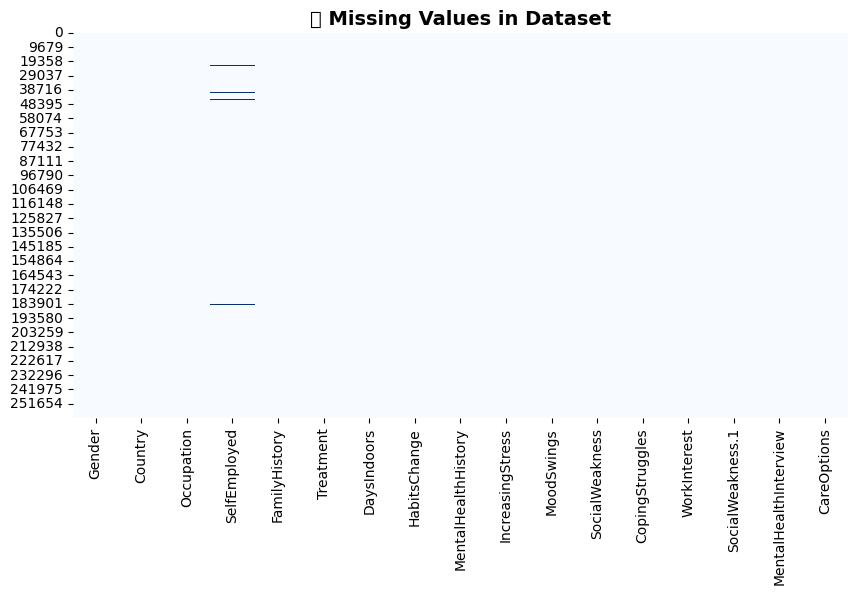

In [13]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='Blues')
plt.title('🔍 Missing Values in Dataset', fontsize=14, weight='bold')
plt.show()


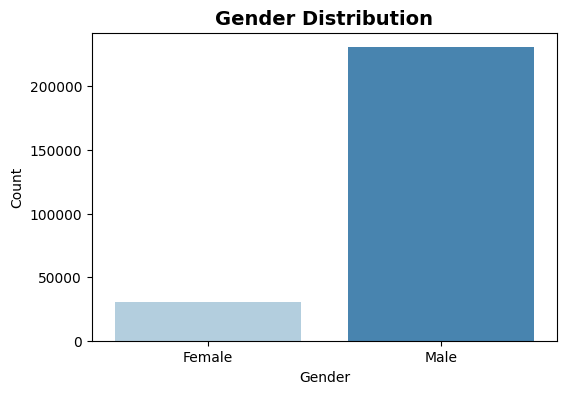

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Blues')
plt.title('Gender Distribution', fontsize=14, weight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


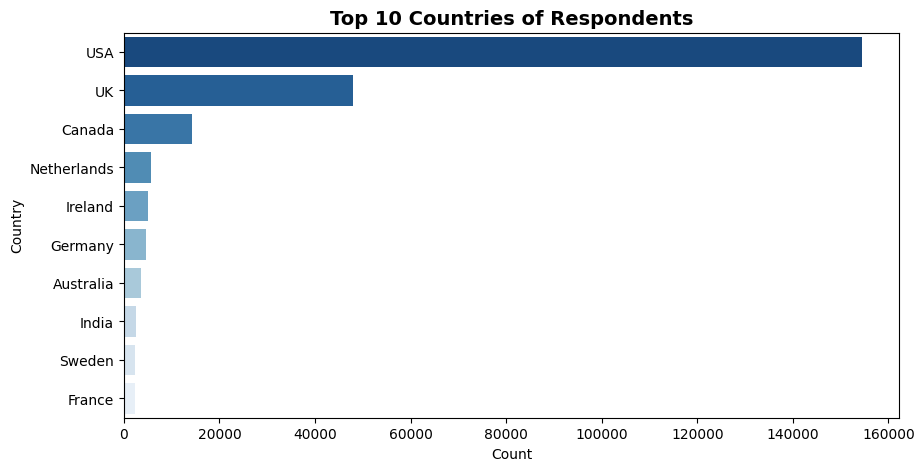

In [15]:
plt.figure(figsize=(10, 5))
top_countries = df['Country'].value_counts().nlargest(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries of Respondents', fontsize=14, weight='bold')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

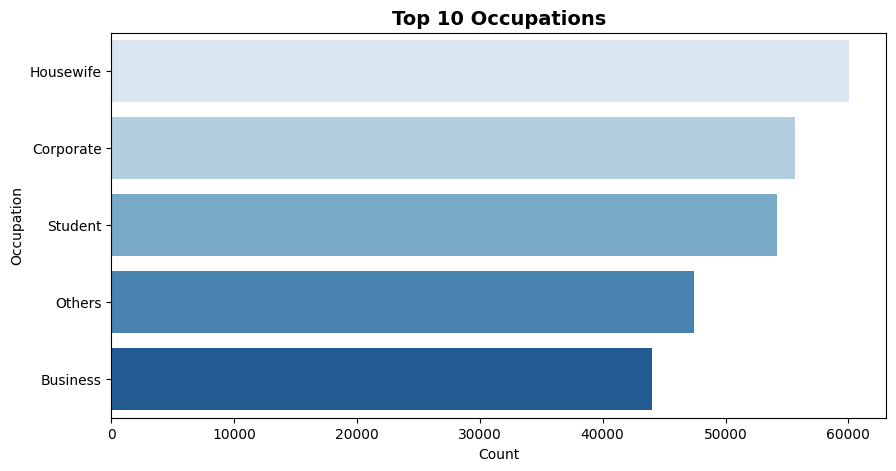

In [16]:
plt.figure(figsize=(10, 5))
top_occ = df['Occupation'].value_counts().nlargest(10)
sns.barplot(x=top_occ.values, y=top_occ.index, palette='Blues')
plt.title('Top 10 Occupations', fontsize=14, weight='bold')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.show()

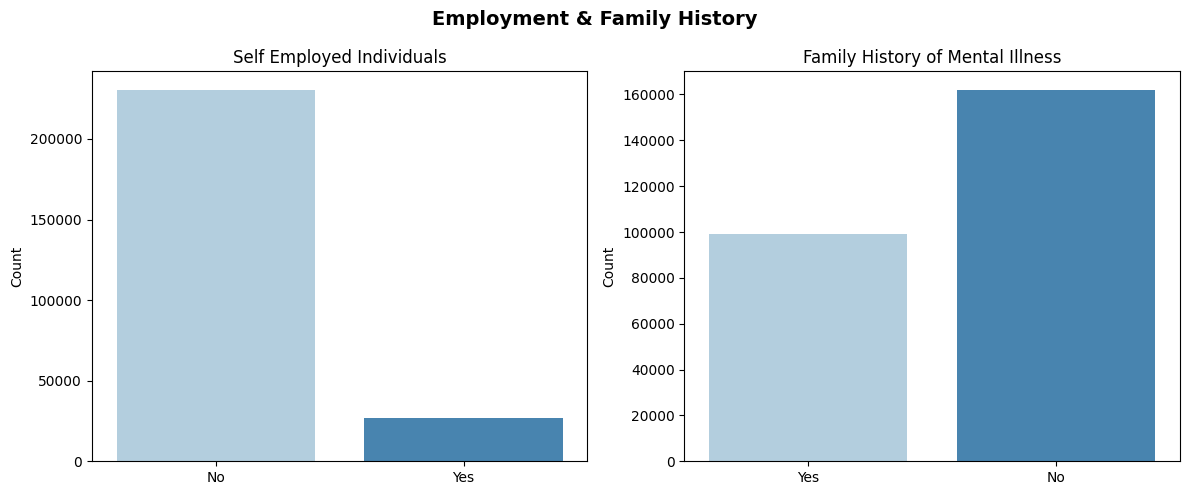

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='SelfEmployed', data=df, ax=ax[0], palette='Blues')
sns.countplot(x='FamilyHistory', data=df, ax=ax[1], palette='Blues')
ax[0].set_title('Self Employed Individuals')
ax[1].set_title('Family History of Mental Illness')
for a in ax:
    a.set_xlabel('')
    a.set_ylabel('Count')
plt.suptitle('Employment & Family History', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

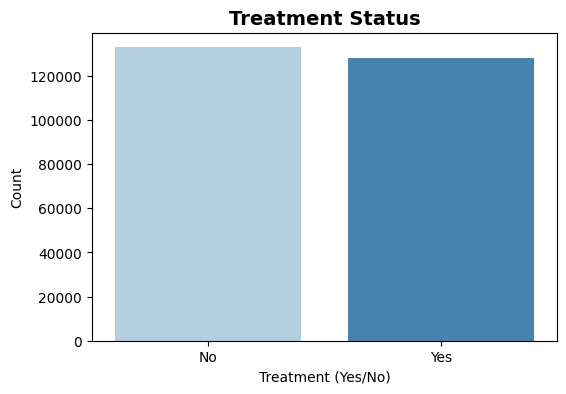

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Treatment', data=df, palette='Blues')
plt.title('Treatment Status', fontsize=14, weight='bold')
plt.xlabel('Treatment (Yes/No)')
plt.ylabel('Count')
plt.show()

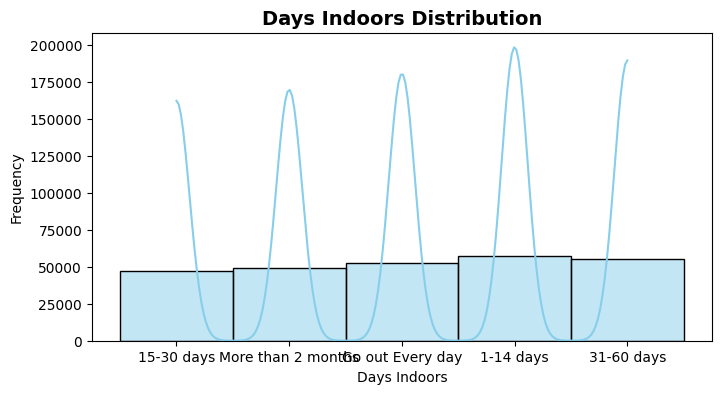

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df['DaysIndoors'], kde=True, color='skyblue', bins=15)
plt.title('Days Indoors Distribution', fontsize=14, weight='bold')
plt.xlabel('Days Indoors')
plt.ylabel('Frequency')
plt.show()


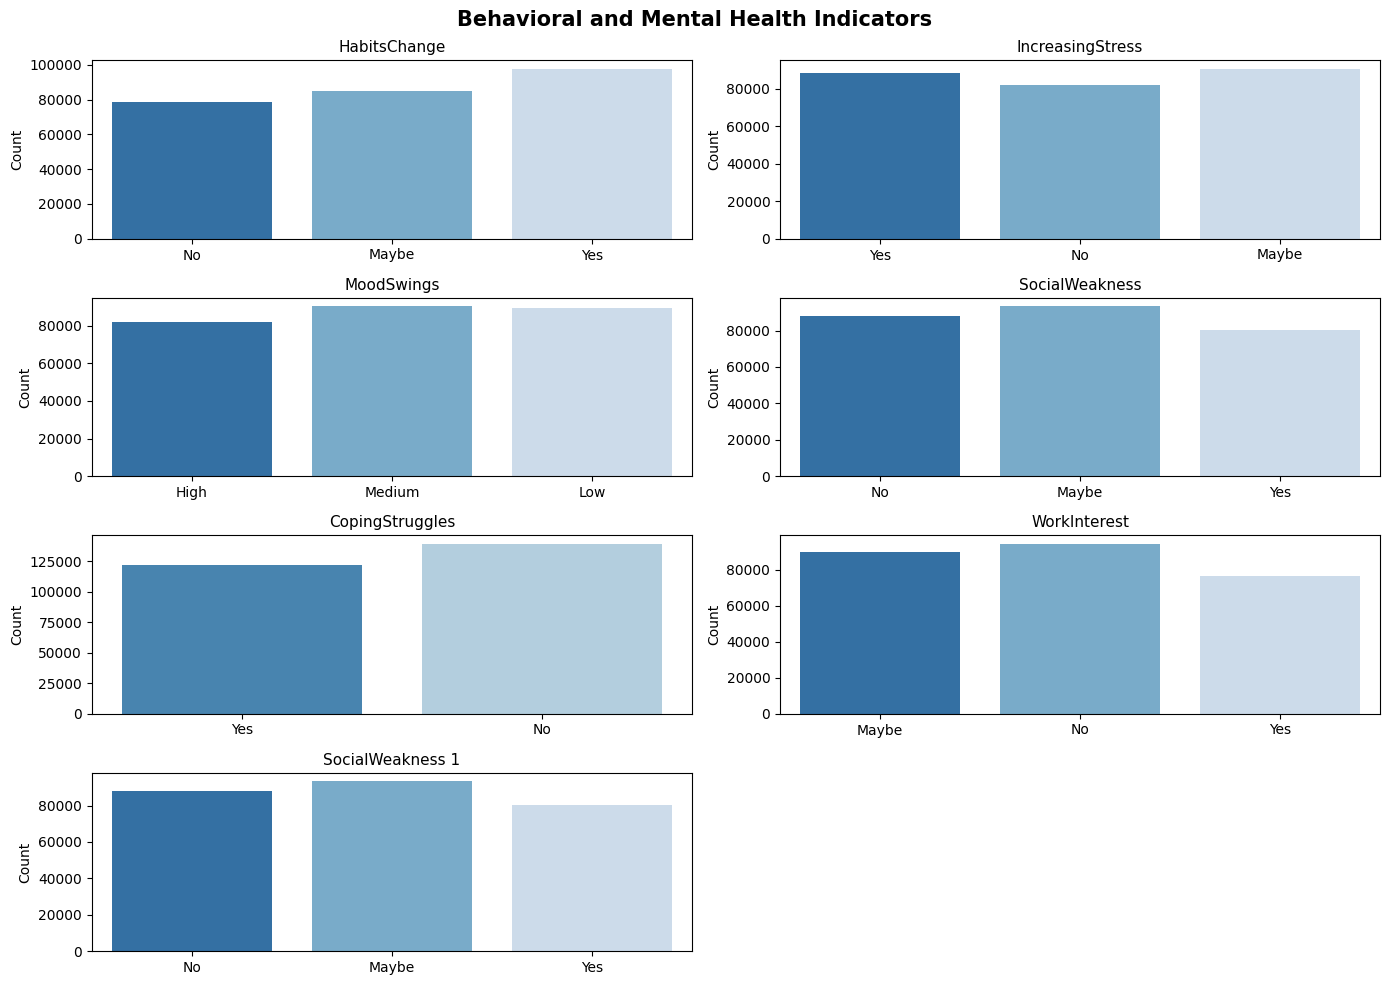

In [20]:
cols = ['HabitsChange', 'IncreasingStress', 'MoodSwings', 'SocialWeakness', 
        'CopingStruggles', 'WorkInterest', 'SocialWeakness.1']

plt.figure(figsize=(14, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(x=col, data=df, palette='Blues_r')
    plt.title(col.replace('.', ' '), fontsize=11)
    plt.xlabel('')
    plt.ylabel('Count')
plt.suptitle('Behavioral and Mental Health Indicators', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

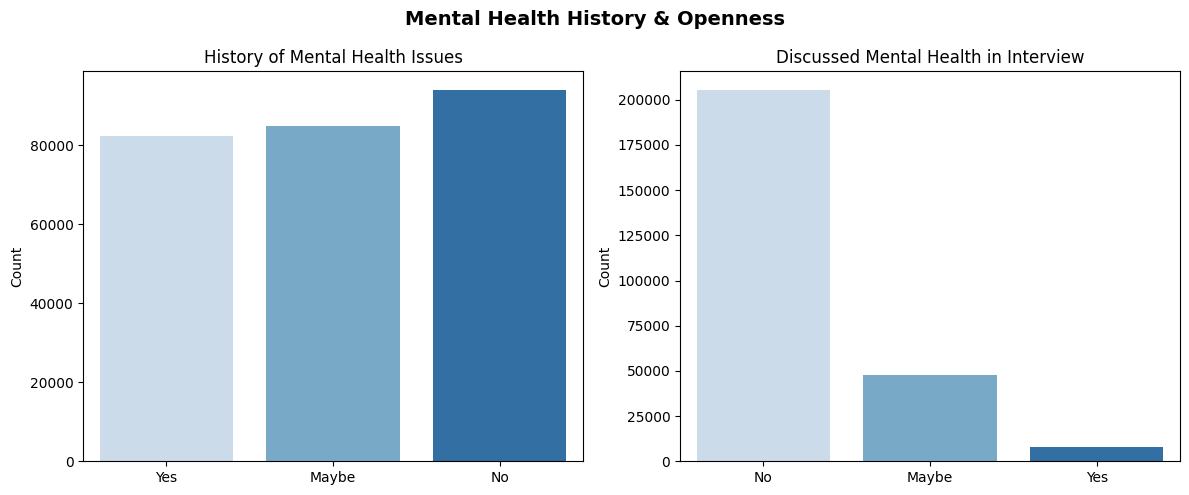

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='MentalHealthHistory', data=df, ax=ax[0], palette='Blues')
sns.countplot(x='MentalHealthInterview', data=df, ax=ax[1], palette='Blues')
ax[0].set_title('History of Mental Health Issues')
ax[1].set_title('Discussed Mental Health in Interview')
for a in ax:
    a.set_xlabel('')
    a.set_ylabel('Count')
plt.suptitle('Mental Health History & Openness', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

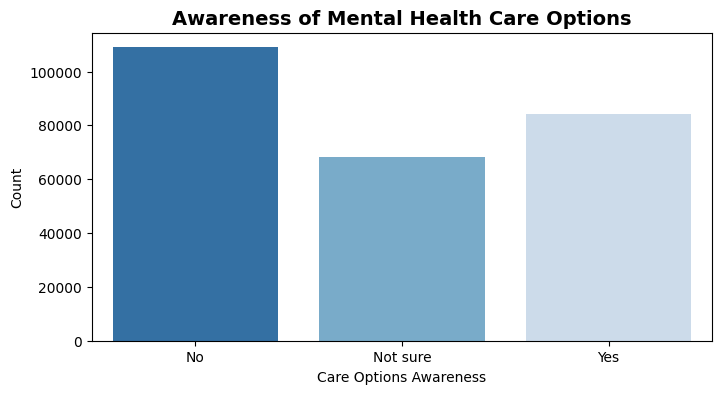

In [22]:
plt.figure(figsize=(8, 4))
sns.countplot(x='CareOptions', data=df, palette='Blues_r')
plt.title('Awareness of Mental Health Care Options', fontsize=14, weight='bold')
plt.xlabel('Care Options Awareness')
plt.ylabel('Count')
plt.show()

In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues')
    plt.title('Correlation Heatmap', fontsize=14, weight='bold')
    plt.show()
else:
    print("No numeric columns to display correlation heatmap.")

No numeric columns to display correlation heatmap.


## ML algorithms

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [25]:
print(df.head())

   Gender Country Occupation SelfEmployed FamilyHistory Treatment  \
0  Female      UK     Others           No           Yes        No   
1  Female     USA  Housewife           No           Yes        No   
2  Female  Canada     Others           No            No       Yes   
3  Female  Canada  Corporate           No           Yes       Yes   
4  Female      UK  Corporate           No            No       Yes   

          DaysIndoors HabitsChange MentalHealthHistory IncreasingStress  \
0          15-30 days           No                 Yes              Yes   
1          15-30 days        Maybe               Maybe              Yes   
2  More than 2 months        Maybe                  No               No   
3    Go out Every day           No               Maybe               No   
4  More than 2 months          Yes                  No            Maybe   

  MoodSwings SocialWeakness CopingStruggles WorkInterest SocialWeakness.1  \
0       High             No             Yes        Maybe 

In [26]:
le = LabelEncoder()
for col in df.columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop('Treatment', axis=1)
y = df['Treatment']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=80)
}


In [30]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 70.02%
Decision Tree Accuracy: 73.36%
Random Forest Accuracy: 74.27%


In [31]:
results_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy (%)'])
results_df = results_df.sort_values(by='Accuracy (%)', ascending=False)


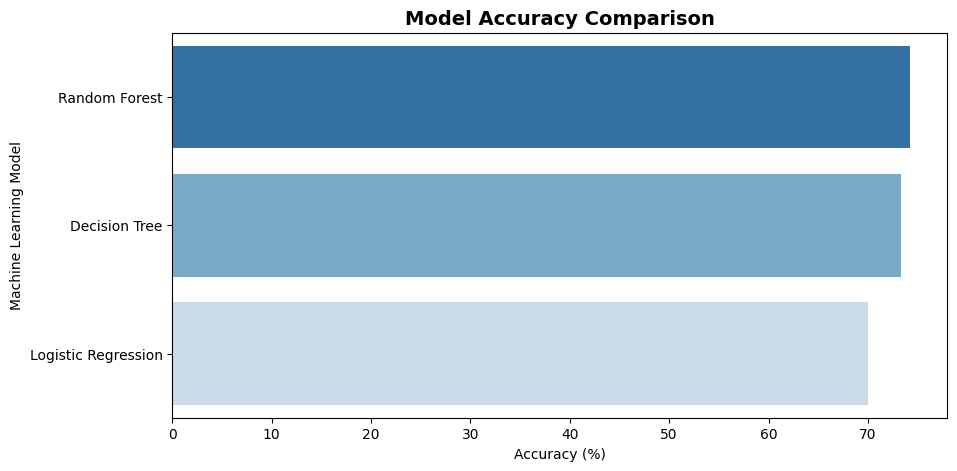

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy (%)', y='Model', data=results_df, palette='Blues_r')
plt.title('Model Accuracy Comparison', fontsize=14, weight='bold')
plt.xlabel('Accuracy (%)')
plt.ylabel('Machine Learning Model')
plt.show()

In [33]:
print("\n🔹 Model Accuracy Summary:")
print(results_df.reset_index(drop=True))


🔹 Model Accuracy Summary:
                 Model  Accuracy (%)
0        Random Forest     74.270080
1        Decision Tree     73.357441
2  Logistic Regression     70.020664


## THank you..pls upvote!!!!!